# Lab 4: Multiple Linear Regression

## Predicting Exam Score from Multiple Student Features

### Dataset

We use the **Student Clean Dataset**.

For this Multiple Linear Regression lab, we use:

- **Input features (X):** `Study_Hours`, `Attendance`, `Assignments`, `Age`
- **Target (y):** `Exam_Score`

The question we investigate is:

> **Can we predict a student's Exam Score using multiple academic and demographic features?**

### Objectives

- Understand Multiple Linear Regression.
- Implement the OLS solution manually using the Normal Equation.
- Generate predictions and residuals.
- Evaluate the model using MAE, MSE, RMSE, and R².
- Implement the same model using Scikit-Learn.
- Compare the manual implementation with Scikit-Learn `LinearRegression`.
- Verify that both implementations agree up to floating-point precision.


# File Structure

### `mlr_ols_student.py`

Contains the completed function implementations:

- `mae()`
- `mse()`
- `r_square()`
- `fit_multiple_lr()`
- `fit_multiple_lr_beta()`
- `predict_multiple_lr()`
- `load_mlr_dataset()`
- `validate_xy()`

### This Notebook

Contains the completed driving code, explanations, plots, Scikit-Learn implementation, comparison tables, verification, and final answers. The core manual functions remain in the Python module.


# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlr_ols_student as mlr


# 2. Load the Dataset

In [2]:
df = mlr.load_mlr_dataset(True)

display(df)


/Users/gourabrajak/Documents/Virtual Env/my_project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


student_clean_dataset.csv already exists. Skipping download.


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18,Male,Computer Science,3,98,12,60,Pass,B,Not Placed,0.00
1,ST002,20,Male,Computer Science,1,81,11,44,Pass,D,Not Placed,0.00
2,ST003,19,Male,Computer Science,3,76,9,46,Pass,D,Not Placed,0.00
3,ST004,19,Female,Computer Science,5,100,10,51,Pass,C,Placed,3.39
4,ST005,18,Female,Computer Science,5,68,13,54,Pass,C,Placed,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...
295,ST296,18,Male,Computer Science,8,86,16,74,Pass,A,Not Placed,0.00
296,ST297,19,Female,Computer Science,9,80,19,92,Pass,A+,Placed,19.43
297,ST298,18,Male,Mechanical,9,81,20,94,Pass,A+,Placed,14.97
298,ST299,19,Male,Computer Science,6,82,18,82,Pass,A+,Placed,7.40


# 3. Check Dataset Size

In [3]:
print('Dataset shape:', df.shape)
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])


Dataset shape: (300, 12)
Number of rows: 300
Number of columns: 12


# 4. Select X and y

In [4]:
feature_names = ['Study_Hours', 'Attendance', 'Assignments', 'Age']
X = df[feature_names].to_numpy(dtype=float)
y = df['Exam_Score'].to_numpy(dtype=float)

mlr.validate_xy(X, y)
print('Features:', feature_names)
print('Target variable: Exam_Score')


X shape: (300, 4)
y shape: (300,)

X data type:
<class 'numpy.ndarray'> float64

y data type:
<class 'numpy.ndarray'> float64

Missing values:
X: 0
y: 0

Number of observations:
X: 300
y: 300

X and y validation successful.
Features: ['Study_Hours', 'Attendance', 'Assignments', 'Age']
Target variable: Exam_Score


# 5. Correlation Heatmap


Correlation Matrix


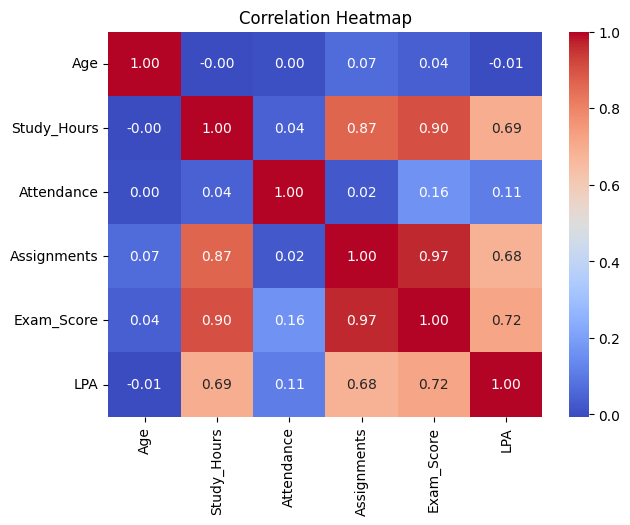

In [5]:
print('\nCorrelation Matrix')
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


# 6. Fit Multiple Linear Regression Using the Normal Equation

The manual model uses the OLS Normal Equation:

$$
\beta = (X^T X)^{-1}X^T y
$$

An intercept column of ones is added inside the supplied function.

In [6]:
beta = mlr.fit_multiple_lr_beta(X, y)

print('Manual OLS coefficients')
print('Intercept:', beta[0])
for feature, coefficient in zip(feature_names, beta[1:]):
    print(f'{feature}: {coefficient:.6f}')


Manual OLS coefficients
Intercept: -11.468386137421476
Study_Hours: 2.083347
Attendance: 0.253975
Assignments: 3.419964
Age: -0.175551


# 7. Verify the Two Manual OLS Function Forms

In [7]:
beta_one_liner = mlr.fit_multiple_lr(X, y)

print('Coefficient vectors match:', np.allclose(beta_one_liner, beta))
print('Maximum absolute coefficient difference:', np.max(np.abs(beta_one_liner - beta)))


Coefficient vectors match: True
Maximum absolute coefficient difference: 3.76054742901033e-12


/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab4/Lab_4_Complete_Student_and_Comparison/mlr_ols_student.py:20: RuntimeWarning: divide by zero encountered in matmul
  beta = np.linalg.inv(X.T @ X) @ X.T @ y
/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab4/Lab_4_Complete_Student_and_Comparison/mlr_ols_student.py:20: RuntimeWarning: overflow encountered in matmul
  beta = np.linalg.inv(X.T @ X) @ X.T @ y
/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab4/Lab_4_Complete_Student_and_Comparison/mlr_ols_student.py:20: RuntimeWarning: invalid value encountered in matmul
  beta = np.linalg.inv(X.T @ X) @ X.T @ y


# 8. Make Predictions with the Manual Model

In [8]:
y_pred = mlr.predict_multiple_lr(X, beta)

manual_results = pd.DataFrame({
    'Actual Exam Score': y,
    'Manual OLS Prediction': y_pred
})
display(manual_results)


/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab4/Lab_4_Complete_Student_and_Comparison/mlr_ols_student.py:36: RuntimeWarning: divide by zero encountered in matmul
  return X @ beta
/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab4/Lab_4_Complete_Student_and_Comparison/mlr_ols_student.py:36: RuntimeWarning: overflow encountered in matmul
  return X @ beta
/Users/gourabrajak/Documents/Virtual Env/my_project/Labs Local/Lab4/Lab_4_Complete_Student_and_Comparison/mlr_ols_student.py:36: RuntimeWarning: invalid value encountered in matmul
  return X @ beta


,Actual Exam Score,Manual OLS Prediction
0,60.0,57.550817
1,44.0,45.295489
2,46.0,41.527933
3,51.0,55.209981
4,54.0,57.518238
...,...,...
295,74.0,78.599714
296,92.0,89.243555
297,94.0,93.093045
298,82.0,80.081499


# 9. Evaluate the Manual Model

In [9]:
manual_mae = mlr.mae(y, y_pred)
manual_mse = mlr.mse(y, y_pred)
manual_rmse = np.sqrt(manual_mse)
manual_r2 = mlr.r_square(y, y_pred, np.mean(y))

print('Manual OLS metrics')
print('MAE :', manual_mae)
print('MSE :', manual_mse)
print('RMSE:', manual_rmse)
print('R²  :', manual_r2)


Manual OLS metrics
MAE : 2.663560784205783
MSE : 9.607167032511889
RMSE: 3.0995430360799783
R²  : 0.9706911473934761


# 10. Actual vs Predicted Plot — Manual OLS

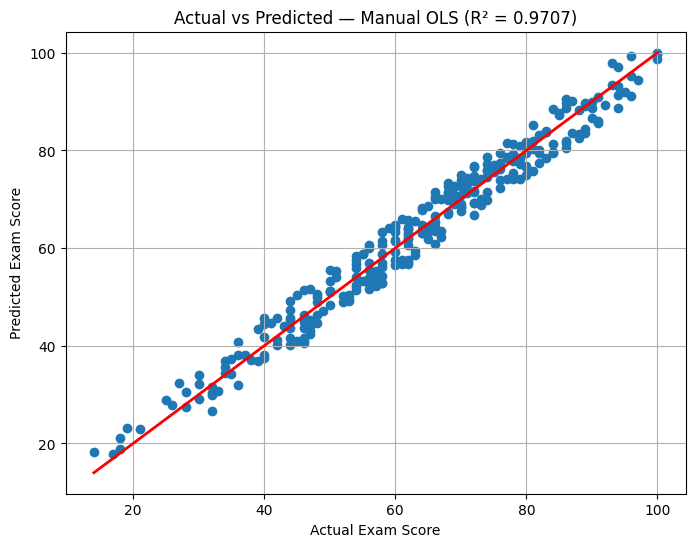

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred)
min_value = min(y.min(), y_pred.min())
max_value = max(y.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linewidth=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title(f'Actual vs Predicted — Manual OLS (R² = {manual_r2:.4f})')
plt.grid(True)
plt.show()


# 11. Residual Plot — Manual OLS

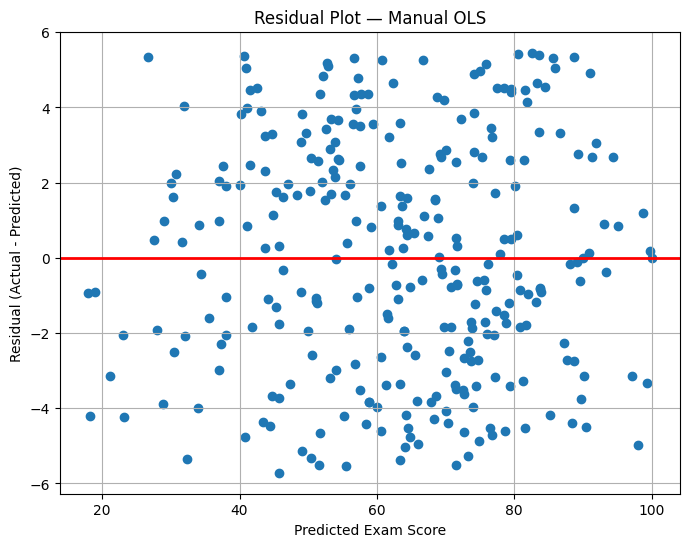

In [11]:
manual_residuals = y - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, manual_residuals)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot — Manual OLS')
plt.grid(True)
plt.show()


# 12. Manual Model Summary

In [12]:
manual_summary = pd.DataFrame({
    'Measure': ['Intercept', *feature_names, 'MAE', 'MSE', 'RMSE', 'R²'],
    'Manual OLS': [beta[0], *beta[1:], manual_mae, manual_mse, manual_rmse, manual_r2]
})
display(manual_summary)


,Measure,Manual OLS
0,Intercept,-11.468386
1,Study_Hours,2.083347
2,Attendance,0.253975
3,Assignments,3.419964
4,Age,-0.175551
5,MAE,2.663561
6,MSE,9.607167
7,RMSE,3.099543
8,R²,0.970691


# 13. Multiple Linear Regression Using Scikit-Learn

In [13]:
sklearn_model = LinearRegression()
sklearn_model.fit(X, y)
print('Scikit-Learn model fitted successfully.')


Scikit-Learn model fitted successfully.


# 14. Scikit-Learn Coefficients

In [14]:
sklearn_intercept = sklearn_model.intercept_
sklearn_coefficients = sklearn_model.coef_

print('Scikit-Learn coefficients')
print('Intercept:', sklearn_intercept)
for feature, coefficient in zip(feature_names, sklearn_coefficients):
    print(f'{feature}: {coefficient:.6f}')


Scikit-Learn coefficients
Intercept: -11.468386137427373
Study_Hours: 2.083347
Attendance: 0.253975
Assignments: 3.419964
Age: -0.175551


# 15. Scikit-Learn Predictions

In [15]:
sklearn_pred = sklearn_model.predict(X)

sklearn_results = pd.DataFrame({
    'Actual Exam Score': y,
    'Scikit-Learn Prediction': sklearn_pred
})
display(sklearn_results)


/Users/gourabrajak/Documents/Virtual Env/my_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gourabrajak/Documents/Virtual Env/my_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gourabrajak/Documents/Virtual Env/my_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Actual Exam Score,Scikit-Learn Prediction
0,60.0,57.550817
1,44.0,45.295489
2,46.0,41.527933
3,51.0,55.209981
4,54.0,57.518238
...,...,...
295,74.0,78.599714
296,92.0,89.243555
297,94.0,93.093045
298,82.0,80.081499


# 16. Scikit-Learn Residuals and Metrics

In [16]:
sklearn_residuals = y - sklearn_pred
sklearn_mae = mean_absolute_error(y, sklearn_pred)
sklearn_mse = mean_squared_error(y, sklearn_pred)
sklearn_rmse = np.sqrt(sklearn_mse)
sklearn_r2 = r2_score(y, sklearn_pred)

print('Scikit-Learn metrics')
print('MAE :', sklearn_mae)
print('MSE :', sklearn_mse)
print('RMSE:', sklearn_rmse)
print('R²  :', sklearn_r2)


Scikit-Learn metrics
MAE : 2.66356078420575
MSE : 9.607167032511885
RMSE: 3.0995430360799774
R²  : 0.9706911473934761


# 17. Residual Plot — Scikit-Learn

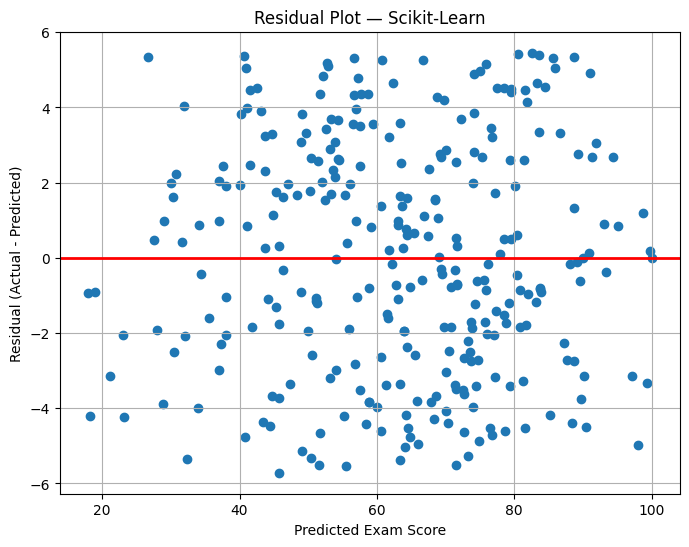

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(sklearn_pred, sklearn_residuals)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot — Scikit-Learn')
plt.grid(True)
plt.show()


# 18. Manual OLS vs Scikit-Learn Comparison

In [18]:
comparison = pd.DataFrame({
    'Measure': ['Intercept', *feature_names, 'MAE', 'MSE', 'RMSE', 'R²'],
    'Manual OLS': [beta[0], *beta[1:], manual_mae, manual_mse, manual_rmse, manual_r2],
    'Scikit-Learn': [sklearn_intercept, *sklearn_coefficients, sklearn_mae, sklearn_mse, sklearn_rmse, sklearn_r2]
})
comparison['Absolute Difference'] = np.abs(comparison['Manual OLS'] - comparison['Scikit-Learn'])
display(comparison)


,Measure,Manual OLS,Scikit-Learn,Absolute Difference
0,Intercept,-11.468386,-11.468386,5.897505e-12
1,Study_Hours,2.083347,2.083347,1.287859e-14
2,Attendance,0.253975,0.253975,5.773160e-15
3,Assignments,3.419964,3.419964,3.730349e-14
4,Age,-0.175551,-0.175551,9.578449e-14
5,MAE,2.663561,2.663561,3.286260e-14
6,MSE,9.607167,9.607167,3.552714e-15
7,RMSE,3.099543,3.099543,8.881784e-16
8,R²,0.970691,0.970691,0.000000e+00


# 19. Compare Predictions

In [19]:
prediction_comparison = pd.DataFrame({
    'Actual Exam Score': y,
    'Manual OLS Prediction': y_pred,
    'Scikit-Learn Prediction': sklearn_pred,
    'Absolute Difference': np.abs(y_pred - sklearn_pred)
})
display(prediction_comparison)
print('Maximum prediction difference:', np.max(np.abs(y_pred - sklearn_pred)))


,Actual Exam Score,Manual OLS Prediction,Scikit-Learn Prediction,Absolute Difference
0,60.0,57.550817,57.550817,3.133493e-12
1,44.0,45.295489,45.295489,3.090861e-12
2,46.0,41.527933,41.527933,3.261391e-12
3,51.0,55.209981,55.209981,3.069545e-12
4,54.0,57.518238,57.518238,3.240075e-12
...,...,...,...,...
295,74.0,78.599714,78.599714,2.984279e-12
296,92.0,89.243555,89.243555,2.785328e-12
297,94.0,93.093045,93.093045,2.856382e-12
298,82.0,80.081499,80.081499,2.856382e-12


Maximum prediction difference: 3.6841640849161195e-12


# 20. Compare Model Coefficients

In [20]:
coefficient_comparison = pd.DataFrame({
    'Feature': ['Intercept', *feature_names],
    'Manual OLS': beta,
    'Scikit-Learn': np.r_[sklearn_intercept, sklearn_coefficients]
})
coefficient_comparison['Absolute Difference'] = np.abs(coefficient_comparison['Manual OLS'] - coefficient_comparison['Scikit-Learn'])
display(coefficient_comparison)


,Feature,Manual OLS,Scikit-Learn,Absolute Difference
0,Intercept,-11.468386,-11.468386,5.897505e-12
1,Study_Hours,2.083347,2.083347,1.287859e-14
2,Attendance,0.253975,0.253975,5.773160e-15
3,Assignments,3.419964,3.419964,3.730349e-14
4,Age,-0.175551,-0.175551,9.578449e-14


# 21. Final Numerical Verification

In [21]:
print('Intercept matches:', np.isclose(beta[0], sklearn_intercept))
print('Coefficients match:', np.allclose(beta[1:], sklearn_coefficients))
print('Predictions match:', np.allclose(y_pred, sklearn_pred))
print('MAE matches:', np.isclose(manual_mae, sklearn_mae))
print('MSE matches:', np.isclose(manual_mse, sklearn_mse))
print('RMSE matches:', np.isclose(manual_rmse, sklearn_rmse))
print('R² matches:', np.isclose(manual_r2, sklearn_r2))


Intercept matches: True
Coefficients match: True
Predictions match: True
MAE matches: True
MSE matches: True
RMSE matches: True
R² matches: True


# 22. Final Interpretation

1. The manual implementation computes the OLS coefficient vector directly from the Normal Equation.
2. Scikit-Learn `LinearRegression` solves the same ordinary least-squares regression problem.
3. Using the same observations, features, target, and intercept convention makes the fitted coefficients and predictions agree up to numerical precision.
4. Matching MAE, MSE, RMSE, and R² values validate the manual implementation against the package implementation.
5. The manual implementation exposes the matrix operations hidden by a high-level machine-learning library API.


# Final Questions — Answers

**1. What does the intercept represent?**  
The predicted Exam Score when all four input features are zero.

**2. What does a regression coefficient represent?**  
The expected change in Exam Score for a one-unit increase in that feature while the other included features are held constant.

**3. What is a residual?**  
The difference between the observed target and its prediction: `actual - predicted`.

**4. What does a positive residual mean?**  
The actual Exam Score is higher than the prediction.

**5. What does a negative residual mean?**  
The actual Exam Score is lower than the prediction.

**6. What does MAE measure?**  
The average absolute size of prediction errors.

**7. What does MSE measure?**  
The average squared prediction error, giving larger errors greater influence.

**8. Why is RMSE the square root of MSE?**  
It returns the error measure to the target variable's original units while retaining the squared-error penalty.

**9. What does R² tell us?**  
The proportion of target variance explained by the fitted regression model.

**10. Why should manual OLS and Scikit-Learn produce almost identical results?**  
They use the same data, features, target, intercept treatment, and ordinary least-squares objective. Tiny differences can arise from floating-point arithmetic.

**11. What is the advantage of implementing the method manually before using a package?**  
It makes the mathematics and matrix operations explicit and helps verify what a high-level library is doing.
